In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

def set_project_plot_style():
    plt.style.use('ggplot')
    plt.rcParams['figure.dpi'] = 100
    plt.rcParams['font.size'] = 10
    sns.set_palette("viridis")
    print("✅ Ekran stili 'kompakt' moda alındı.")

def clean_label(label):
    return label.replace("_", " ").replace("-", " ").title()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(true_labels, pred_labels, class_names):
    report = classification_report(true_labels, pred_labels,
                                   target_names=class_names,
                                   output_dict=True)

    print("--- Model Değerlendirme Raporu ---")
    print(classification_report(true_labels, pred_labels, target_names=class_names))

    return report

In [ ]:
import json
import os

def save_results(sonuclar):
    os.makedirs('artifacts/reports/', exist_ok=True)

    file_path = 'artifacts/reports/evaluation_results.json'
    with open(file_path, 'w') as f:
        json.dump(sonuclar, f, indent=4)

    print(f"Rapor başarıyla '{file_path}' adresine kaydedildi!")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, class_names, split_name="Test", normalize=False):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.title(f'Hata Matrisi - {split_name}', fontsize=10)
    plt.ylabel('Gerçek', fontsize=9)
    plt.xlabel('Tahmin', fontsize=9)

    os.makedirs('artifacts/figures/', exist_ok=True)
    plt.savefig(f'artifacts/figures/cm_{split_name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
def plot_prediction_gallery(images, true_labels, pred_labels, confidences, class_names):
    num_to_show = len(images)

    plt.figure(figsize=(10, 8))

    for i in range(min(num_to_show, 20)):
        plt.subplot(4, 5, i + 1)
        plt.imshow(images[i])

        is_correct = pred_labels[i] == true_labels[i]
        color = 'green' if is_correct else 'red'

        plt.title(f"P:{class_names[pred_labels[i]][:5]}\nT:{class_names[true_labels[i]][:5]}",
                  color=color, fontsize=8)
        plt.axis('off')

    plt.tight_layout()

    save_path = 'artifacts/sample_outputs/'
    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, 'prediction_gallery.png'), dpi=300)
    plt.show()

In [ ]:
!pip install grad-cam

In [ ]:
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt
import os

def generate_grad_cam_visualization(model, input_tensor, rgb_img, target_layer, file_name="grad_cam_result"):
    """
    Issue #10 Düzeltmesi: Orijinal, Isı Haritası ve Overlay görüntülerini yanyana kaydeder.
    """
    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(np.argmax(model(input_tensor).detach().numpy()))]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb_img)
    plt.title("Orijinal Resim", fontsize=10)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(grayscale_cam, cmap='jet')
    plt.title("Isı Haritası (Heatmap)", fontsize=10)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(visualization)
    plt.title("Overlay Blend", fontsize=10)
    plt.axis('off')

    os.makedirs('artifacts/figures/', exist_ok=True)
    save_path = f'artifacts/figures/{file_name}_triple.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Üçlü Grad-CAM görseli kaydedildi: {save_path}")

✅ Ekran stili 'kompakt' moda alındı.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Test süreci başlatılıyor...

--- Model Değerlendirme Raporu ---
                 precision    recall  f1-score   support

       Saglikli       0.40      0.50      0.44         4
   Pasli_Yaprak       0.33      0.30      0.32        10
Bakteriyel_Leke       0.00      0.00      0.00         6

       accuracy                           0.25        20
      macro avg       0.24      0.27      0.25        20
   weighted avg       0.25      0.25      0.25        20

Rapor başarıyla 'artifacts/reports/evaluation_results.json' adresine kaydedildi!


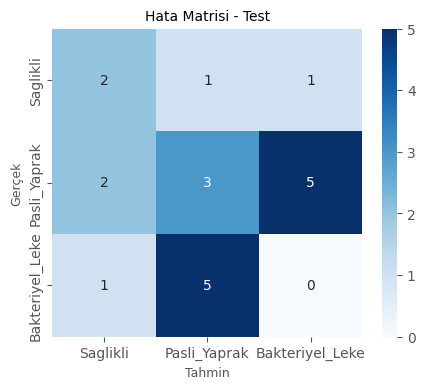

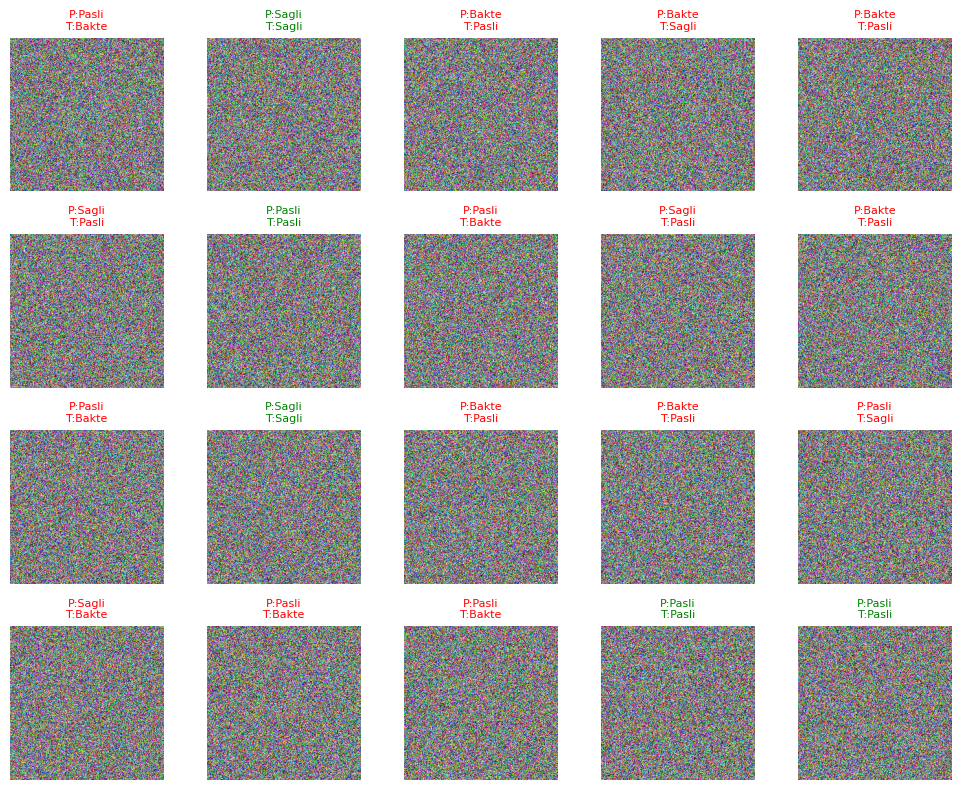

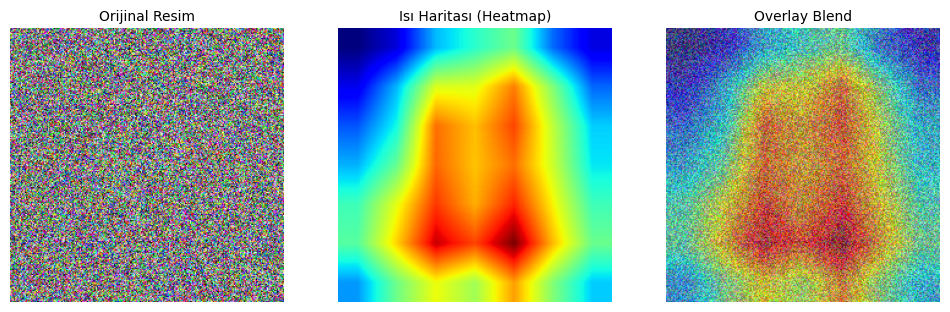

✅ Üçlü Grad-CAM görseli kaydedildi: artifacts/figures/grad_cam_result_triple.png

🎉 Tebrikler! Tüm 'artifact' dosyaları başarıyla üretildi.


In [ ]:
import torch
from torchvision.models import mobilenet_v2

set_project_plot_style()

class_names = ['Saglikli', 'Pasli_Yaprak', 'Bakteriyel_Leke']
dummy_labels = np.random.randint(0, 3, 20)
dummy_preds = np.random.randint(0, 3, 20)
dummy_confs = np.random.uniform(0.7, 0.99, 20)
dummy_imgs = [np.random.rand(224, 224, 3) for _ in range(20)]

model = mobilenet_v2(pretrained=True).eval()
input_tensor = torch.randn(1, 3, 224, 224)

print("🚀 Test süreci başlatılıyor...\n")

rapor = evaluate_model(dummy_labels, dummy_preds, class_names)
save_results(rapor)

plot_confusion_matrix(dummy_labels, dummy_preds, class_names)

plot_prediction_gallery(dummy_imgs, dummy_labels, dummy_preds, dummy_confs, class_names)

generate_grad_cam_visualization(model, input_tensor, dummy_imgs[0], model.features[-1])

print("\n🎉 Tebrikler! Tüm 'artifact' dosyaları başarıyla üretildi.")

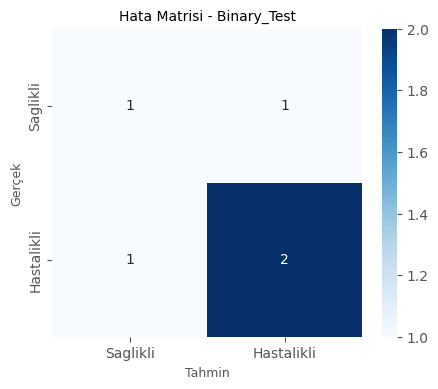

In [ ]:
binary_class_names = ['Saglikli', 'Hastalikli']
binary_true = [0, 1, 0, 1, 1]
binary_pred = [0, 1, 1, 1, 0]

plot_confusion_matrix(binary_true, binary_pred, binary_class_names, split_name="Binary_Test")

📊 Toplam Hatalı Tahmin Sayısı: 15

🔍 Hata Analizi Odak Noktası (Index: 0)
Gerçek Sınıf: Bakteriyel_Leke | Tahmin: Pasli_Yaprak | Güven: 0.87

📸 Modelin yanlış yere odaklanıp odaklanmadığını kontrol ediyoruz...


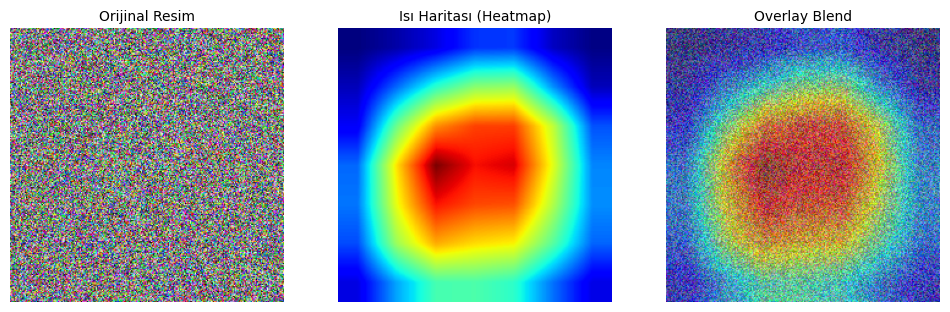

✅ Üçlü Grad-CAM görseli kaydedildi: artifacts/figures/failure_case_analysis_triple.png


In [41]:
import numpy as np
import matplotlib.pyplot as plt

misclassified_indices = np.where(dummy_labels != dummy_preds)[0]

print(f"📊 Toplam Hatalı Tahmin Sayısı: {len(misclassified_indices)}")

if len(misclassified_indices) > 0:

    fail_idx = misclassified_indices[0]

    true_label = class_names[dummy_labels[fail_idx]]
    pred_label = class_names[dummy_preds[fail_idx]]
    conf_score = dummy_confs[fail_idx]

    print(f"\n🔍 Hata Analizi Odak Noktası (Index: {fail_idx})")
    print(f"Gerçek Sınıf: {true_label} | Tahmin: {pred_label} | Güven: {conf_score:.2f}")

    single_img_tensor = torch.from_numpy(dummy_imgs[fail_idx]).permute(2, 0, 1).unsqueeze(0).float()

    print("\n📸 Modelin yanlış yere odaklanıp odaklanmadığını kontrol ediyoruz...")
    generate_grad_cam_visualization(
        model,
        single_img_tensor,
        dummy_imgs[fail_idx],
        model.features[-1],
        file_name="failure_case_analysis"
    )
else:
    print("Mükemmel sonuç! Analiz edilecek hata bulunamadı.")